In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [30]:
# # ---two-way comparison---
# model1 = 'remitter_mdd_bp_nppv'
# model2 = 'remitter_mdd_dyna_all_nppv'
# dataset1 = 'Demographic + Bandpower'
# dataset2 = 'Demographic + Dynamix Features'
# response_var_cap = 'Remitter'
# eval_metric = 'nPPV'

# ---three-way comparison---
model1 = 'remitter_mdd_nppv'
model2 = 'remitter_mdd_bp_nppv'
model3 = 'remitter_mdd_dyna_all_nppv'
dataset1 = 'Demographic Only'
dataset2 = 'Demographic + Bandpower'
dataset3 = 'Demographic + Dynamix Features'
response_var_cap = 'Remitter'
eval_metric = 'nPPV'

In [31]:
# # ---two-way comparison---
df1 = pd.read_csv(f'../../results/summary/{model1}_summary.csv')
df2 = pd.read_csv(f'../../results/summary/{model2}_summary.csv')

# combine the DataFrames
combined_df = pd.concat([df1, df2], ignore_index=True)

datasets_list = [df1, df2]
dataset_labels = [dataset1, dataset2]
models = df1.columns.values

# # ---three-way comparison---
# df1 = pd.read_csv(f'../../results/summary/{model1}_summary.csv')
# df2 = pd.read_csv(f'../../results/summary/{model2}_summary.csv')
# df3 = pd.read_csv(f'../../results/summary/{model3}_summary.csv')

# # combine the DataFrames
# combined_df = pd.concat([df1, df2, df3], ignore_index=True)

# datasets_list = [df1, df2, df3]
# dataset_labels = [dataset1, dataset2, dataset3]
# models = df1.columns.values

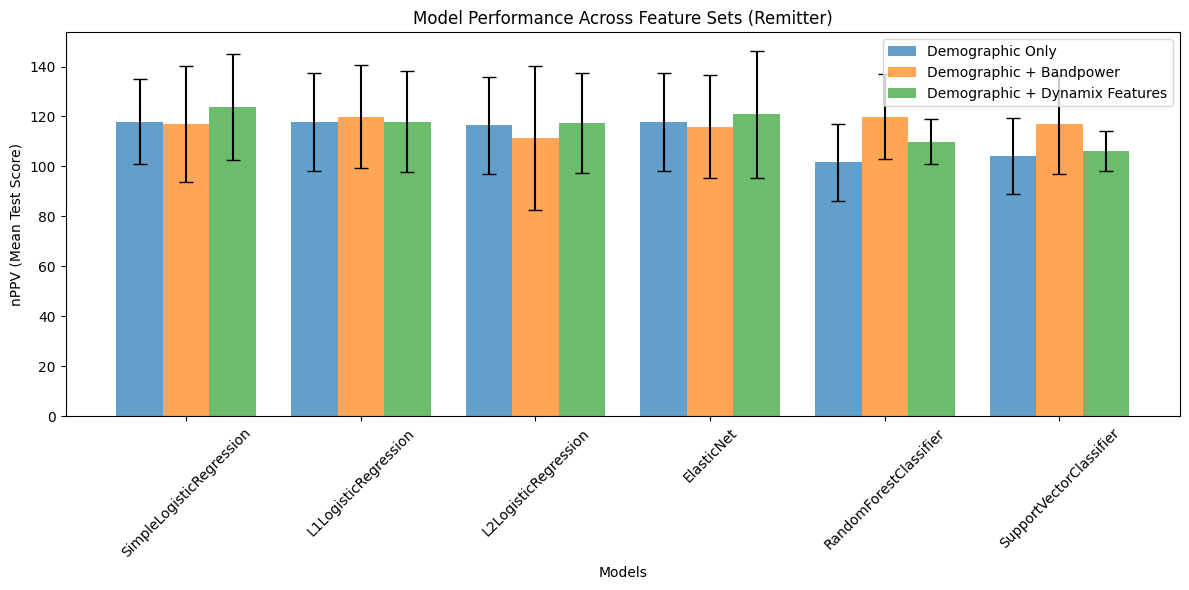

In [32]:
num_datasets = len(datasets_list)
x = np.arange(len(models))
width = 0.8 / num_datasets  # total width split evenly among groups

fig, ax = plt.subplots(figsize=(12,6))

# loop over datasets
for i, (df, label) in enumerate(zip(datasets_list, dataset_labels)):
    means = df.iloc[1].values  # row 1 = mean
    stds = df.iloc[2].values   # row 2 = std
    ax.bar(x + (i - num_datasets/2 + 0.5)*width, means, width, yerr=stds, capsize=5, alpha=0.7, label=label)
    
# labels and title
ax.set_xlabel('Models')
ax.set_ylabel(f'{eval_metric} (Mean Test Score)')
ax.set_title(f'Model Performance Across Feature Sets ({response_var_cap})')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)
# ax.set_ylim(0, 1)

ax.legend()
plt.tight_layout()
plt.show()